In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
path = '/content/drive/MyDrive/TFG/Data_prueba/esgcclbp'

In [4]:
df_min = pd.read_csv(path+'/es1min.txt')
print(df_min.head(), len(df_min))
df_dia = pd.read_csv(path+'/es1dia.txt')
print(df_dia.head(), len(df_dia))

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>   <OPEN>   <HIGH>    <LOW>  <CLOSE>  \
0       ES     I      20151209   70100  2063.00  2063.25  2063.00  2063.25   
1       ES     I      20151209   70200  2063.25  2063.50  2063.00  2063.50   
2       ES     I      20151209   70300  2063.25  2063.50  2063.25  2063.50   
3       ES     I      20151209   70400  2063.50  2063.50  2063.25  2063.50   
4       ES     I      20151209   70500  2063.25  2063.50  2063.25  2063.50   

   <VOL>  <OPENINT>  
0     60          0  
1     37          0  
2     26          0  
3     11          0  
4      6          0   2579332
  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>  <OPEN>  <HIGH>   <LOW>  <CLOSE>  \
0       ES     D      19970911       0  918.75  929.75  910.25   916.00   
1       ES     D      19970912       0  918.00  936.50  913.50   918.75   
2       ES     D      19970915       0  933.50  939.75  929.00   931.25   
3       ES     D      19970916       0  931.25  960.00  930.25   956.00   
4       ES     D

In [5]:
from datetime import time

df_min['date_str'] = df_min['<DTYYYYMMDD>'].astype(str)
df_min['time_str'] = df_min['<TIME>'].astype(str).str.zfill(6)

# Crear datetime
df_min['datetime'] = pd.to_datetime(
    df_min['date_str'] + df_min['time_str'],
    format='%Y%m%d%H%M%S'
)
df_min['datetime'] = pd.to_datetime(df_min['datetime'])
df_min['date'] = df_min['datetime'].dt.normalize()
df_min['time'] = df_min['datetime'].dt.time

# Filtrar ventana 03:30–03:44 y ordenar
df_open_mins = df_min[
    (df_min['time'] >= time(15, 30)) &
    (df_min['time'] <= time(15, 44))
].copy()
df_open_mins = (
    df_open_mins
    .sort_values(['date', 'datetime'])
    .assign(min_id=lambda x: x.groupby('date').cumcount() + 1)
)
df_open_mins = df_open_mins.rename(columns={
    '<OPEN>': 'OPEN',
    '<HIGH>': 'HIGH',
    '<LOW>': 'LOW',
    '<CLOSE>': 'CLOSE',
    '<VOL>': 'VOL',
    '<OPENINT>': 'OPENINT'
})
df_open_mins.head()

,<TICKER>,<PER>,<DTYYYYMMDD>,<TIME>,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,date_str,time_str,datetime,date,time,min_id
508,ES,I,20151209,153000,2054.75,2055.75,2054.50,2054.50,2722,0,20151209,153000,2015-12-09 15:30:00,2015-12-09,15:30:00,1
509,ES,I,20151209,153100,2054.75,2056.00,2054.00,2055.75,13361,0,20151209,153100,2015-12-09 15:31:00,2015-12-09,15:31:00,2
510,ES,I,20151209,153200,2055.75,2057.25,2055.50,2056.75,10974,0,20151209,153200,2015-12-09 15:32:00,2015-12-09,15:32:00,3
511,ES,I,20151209,153300,2056.75,2057.50,2055.25,2057.00,11307,0,20151209,153300,2015-12-09 15:33:00,2015-12-09,15:33:00,4
512,ES,I,20151209,153400,2057.25,2058.25,2055.75,2056.00,8663,0,20151209,153400,2015-12-09 15:34:00,2015-12-09,15:34:00,5


In [6]:
cols = [
    'date', 'min_id',
    'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL', 'OPENINT'
]
df_open_mins = df_open_mins[cols]
df_pivot = df_open_mins.pivot(
    index='date',
    columns='min_id',
    values=['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
)
df_pivot.columns = [
    f"m{min_id}_{var.lower()}"
    for var, min_id in df_pivot.columns
]

df_pivot = df_pivot.reset_index()
df_pivot

,date,m1_open,m2_open,m3_open,m4_open,m5_open,m6_open,m7_open,m8_open,m9_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,2015-12-09,2054.75,2054.75,2055.75,2056.75,2057.25,2056.00,2054.75,2057.75,2060.00,...,7813.0,7851.0,16967.0,12791.0,9258.0,8331.0,10475.0,11623.0,8201.0,6521.0
1,2015-12-10,2039.00,2038.75,2039.50,2038.00,2037.00,2037.00,2036.75,2037.50,2040.50,...,1485.0,2023.0,3146.0,1440.0,2281.0,1626.0,1616.0,869.0,2889.0,1150.0
2,2015-12-11,2017.25,2017.50,2017.25,2018.75,2019.00,2020.75,2020.25,2019.75,2018.50,...,6184.0,9881.0,6026.0,9881.0,6429.0,9502.0,4864.0,5729.0,5869.0,5905.0
3,2015-12-14,2005.00,2004.50,2004.75,2002.25,2004.25,2005.75,2008.75,2009.50,2008.50,...,10715.0,11052.0,12481.0,12814.0,4986.0,6077.0,6464.0,5238.0,6485.0,7764.0
4,2015-12-15,2031.00,2031.25,2031.75,2033.75,2036.25,2035.50,2034.50,2035.00,2035.00,...,8136.0,10897.0,8971.0,11341.0,6849.0,7731.0,11060.0,7622.0,6522.0,7347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896,2023-09-13,4515.25,4515.25,4518.75,4523.00,4524.25,4520.00,4521.25,4523.25,4522.75,...,3084.0,3445.0,3206.0,3386.0,3390.0,2939.0,3052.0,2430.0,2719.0,3414.0
1897,2023-09-14,4540.25,4542.25,4538.25,4536.25,4539.00,4540.25,4537.25,4539.25,4539.25,...,4137.0,3791.0,3500.0,3335.0,3629.0,3784.0,2517.0,2329.0,2868.0,2158.0
1898,2023-09-15,4537.50,4537.00,4538.50,4537.25,4534.00,4535.50,4536.50,4537.25,4536.50,...,5680.0,4519.0,4487.0,4193.0,3301.0,4017.0,3040.0,3914.0,4130.0,4305.0
1899,2023-09-18,4494.25,4494.75,4495.75,4493.75,4493.25,4497.25,4498.50,4499.00,4499.00,...,4062.0,3207.0,3898.0,3578.0,3403.0,3136.0,4168.0,3589.0,4522.0,2777.0


In [7]:
# Crear date (solo fecha, sin hora)
df_dia['date'] = pd.to_datetime(
    df_dia['<DTYYYYMMDD>'],
    format='%Y%m%d'
)

# Renombrar columnas OHLC diarias
df_dia = df_dia.rename(columns={
    '<OPEN>': 'D_OPEN',
    '<HIGH>': 'D_HIGH',
    '<LOW>': 'D_LOW',
    '<CLOSE>': 'D_CLOSE',
    '<VOL>': 'D_VOL',
    '<OPENINT>': 'D_OPENINT'
})
df_dia.drop(columns=['<DTYYYYMMDD>', '<PER>', '<TIME>', '<TICKER>'], inplace=True)
df_dia.head()

,D_OPEN,D_HIGH,D_LOW,D_CLOSE,D_VOL,D_OPENINT,date
0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11
1,918.00,936.50,913.50,918.75,9759,4059,1997-09-12
2,933.50,939.75,929.00,931.25,8551,3818,1997-09-15
3,931.25,960.00,930.25,956.00,11749,5314,1997-09-16
4,956.00,962.50,951.50,956.00,10849,5516,1997-09-17


In [8]:
df_final = df_dia.merge(
    df_pivot,
    on='date',
    how='left'
)
df_final.head()

,D_OPEN,D_HIGH,D_LOW,D_CLOSE,D_VOL,D_OPENINT,date,m1_open,m2_open,m3_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,918.00,936.50,913.50,918.75,9759,4059,1997-09-12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,933.50,939.75,929.00,931.25,8551,3818,1997-09-15,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,931.25,960.00,930.25,956.00,11749,5314,1997-09-16,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,956.00,962.50,951.50,956.00,10849,5516,1997-09-17,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Columnas de minutos
cols_mins = [col for col in df_final.columns if col.startswith('m')]

# Crear columna temporal año
df_final['year'] = df_final['date'].dt.year

# Contar días con NaN por año
nan_summary = df_final.groupby('year').apply(
    lambda x: pd.Series({
        'total_dias': len(x),
        'dias_con_nan': x[cols_mins].isna().any(axis=1).sum(),
        'dias_completos': len(x) - x[cols_mins].isna().any(axis=1).sum()
    })
).reset_index()

print(nan_summary)

    year  total_dias  dias_con_nan  dias_completos
0   1997          78            78               0
1   1998         252           252               0
2   1999         252           252               0
3   2000         252           252               0
4   2001         249           249               0
5   2002         251           251               0
6   2003         254           254               0
7   2004         259           259               0
8   2005         258           258               0
9   2006         257           257               0
10  2007         259           259               0
11  2008         258           258               0
12  2009         257           257               0
13  2010         253           253               0
14  2011         252           252               0
15  2012         253           253               0
16  2013         252           252               0
17  2014         252           252               0
18  2015         254           

/tmp/ipykernel_1306/3739915113.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_summary = df_final.groupby('year').apply(


No todos los años cuentan con valores de minutos. No podemos eliminar directamente los NaN porque entonces nos quedaríamos con pocos datos y sería poca muestra. Vamos a utilizar la siguiente estrategia:

Para los modelos que soportan NaN-> mantener. Se va a mantener los Nan para modelos como XGBoost porque lo pueden soportar y así comprobamos.
Para los modelos que no lo soportan -> Se reemplazará por la mediana. En caso de no obtener buenos resultados también se va a probar a eliminar las filas que tienen NaN.

# Cáclculo de parámetros

## Diario:

 displ= ((high+low)/2)- open  Para el día. Para ello guardamos los máximos, mínimos y de apertura en vectoeres.

In [10]:
high = df_final['D_HIGH']
low = df_final['D_LOW']
open_ = df_final['D_OPEN']
close = df_final['D_CLOSE']
vol = df_final['D_VOL']

df_final['DISPLAY'] = ((high + low) / 2) - open_

Ahora se va a determinar BULLISH (es un valor que depende de displ, en caso de que displ sea positivo implica que es verdadero, si es falso es que es negativo)

In [11]:
df_final['BULLISH'] = df_final['DISPLAY'] > 0

Definición del set de predictor en base a días anteriores:

1. El vactor de características incorporará variables que se corresponden con los 5 días anteriores. (Cómo la media o varianza).
2. Así mismo también incorporará variables del intervalo tomado al principio del día.

Variables:

- p5_close_open, p4_close_open, p3_close_open, p2_close_open, p1_close_open. Se corresponderán conn los vectores de características, p5 indica que es de 5 días antes, p4 de cuatro día antes... Se corresponde con el valor de cierre menos el valor de apertura.
- La media y la desviación típica de estos 5 valores en los días anteriores se incorpora también (p_close_open_mean y p_close_open_sd)

In [12]:
df_final['CLOSE_OPEN'] = close - open_
for i in range(1, 6):
    df_final[f'p{i}_close_open'] = df_final['CLOSE_OPEN'].shift(i)

df_final['p_close_open_mean'] = df_final[
    [f'p{i}_close_open' for i in range(1, 6)]
].mean(axis=1)

df_final['p_close_open_sd'] = df_final[
    [f'p{i}_close_open' for i in range(1, 6)]
].std(axis=1)


for i in range(1, 6):
    df_final[f'p{i}_high_low'] = high.shift(i) - low.shift(i)

for i in range(1, 6):
    df_final[f'p{i}_is_bullish'] = df_final['BULLISH'].shift(i)

df_final['HINGE'] = (high - low) / 2

for i in range(1, 6):
    df_final[f'p{i}_HINGE'] = df_final['HINGE'].shift(i)

df_final['p_HINGE_mean'] = df_final[
    [f'p{i}_HINGE' for i in range(1, 6)]
].mean(axis=1)

df_final['p_HINGE_sd'] = df_final[
    [f'p{i}_HINGE' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_volume'] = vol.shift(i)

df_final['p_volume_mean'] = df_final[
    [f'p{i}_volume' for i in range(1, 6)]
].mean(axis=1)

df_final['p_volume_sd'] = df_final[
    [f'p{i}_volume' for i in range(1, 6)]
].std(axis=1)

for i in range(1, 6):
    df_final[f'p{i}_display'] = df_final['DISPLAY'].shift(i)

Los gaps representan la diferencia entre el precio de apertura del día y el cierre del día anterior.
Son fundamentales en trading porque condensan mucha información sobre sentimiento del mercado, reacción a noticias, y volatilidad nocturna.

Variables añadidas:

- prev_close → cierre del día anterior

- gap_abs → diferencia OPEN - CLOSE_prev

- gap_pct → tamaño del gap en porcentaje

- gap_dir → 1 si gap alcista, 0 si bajista

- gap_zscore → gap estandarizado (compara el gap actual con los últimos 20 días)

In [13]:
# Cierre del día previo
df_final['prev_close'] = df_final['D_CLOSE'].shift(1)

# Gap absoluto: mide si el mercado abre por encima o por debajo del cierre previo
df_final['gap_abs'] = df_final['D_OPEN'] - df_final['prev_close']

# Gap porcentual: gap relativo al precio
df_final['gap_pct'] = df_final['gap_abs'] / df_final['prev_close']

# Dirección del gap: 1 si es alcista, 0 si es bajista
df_final['gap_dir'] = (df_final['gap_abs'] > 0).astype(int)

# Gap Z-score: gap actual comparado con su media y desviación de 20 días
df_final['gap_zscore'] = (
    df_final['gap_pct'] - df_final['gap_pct'].rolling(20).mean()
) / df_final['gap_pct'].rolling(20).std()

# Gaps de días anteriores (últimos 5 días)
for i in range(1, 6):
    df_final[f'p{i}_gap_abs'] = df_final['gap_abs'].shift(i)
    df_final[f'p{i}_gap_pct'] = df_final['gap_pct'].shift(i)
    df_final[f'p{i}_gap_dir'] = df_final['gap_dir'].shift(i)
    df_final[f'p{i}_gap_zscore'] = df_final['gap_zscore'].shift(i)


El True Range mide la volatilidad real del día considerando el rango de precios y los gaps.
El ATR (Average True Range) suaviza esa volatilidad en el tiempo.

Variables añadidas:

- true_range → volatilidad real del día

- ATR_5, ATR_10 → volatilidad reciente y suavizada

- ATR_zscore → volatilidad anormalmente alta o baja

In [14]:
import numpy as np

# High y Low del día previo
df_final['prev_high'] = df_final['D_HIGH'].shift(1)
df_final['prev_low'] = df_final['D_LOW'].shift(1)

# True Range: máxima distancia relevante del día
tr1 = df_final['D_HIGH'] - df_final['D_LOW']
tr2 = (df_final['D_HIGH'] - df_final['prev_close']).abs()
tr3 = (df_final['D_LOW'] - df_final['prev_close']).abs()
df_final['true_range'] = np.maximum.reduce([tr1, tr2, tr3])

# ATR a 5 y 10 días
df_final['ATR_5'] = df_final['true_range'].rolling(5).mean()
df_final['ATR_10'] = df_final['true_range'].rolling(10).mean()

# ATR Z-score: volatilidad actual comparada con 20 días
df_final['ATR_zscore'] = (
    df_final['ATR_5'] - df_final['ATR_5'].rolling(20).mean()
) / df_final['ATR_5'].rolling(20).std()

for i in range(1, 6):
    # TR de hace i días
    df_final[f'lag{i}_true_range'] = df_final['true_range'].shift(i)

    # ATR de hace i días
    df_final[f'lag{i}_ATR_5'] = df_final['ATR_5'].shift(i)
    df_final[f'lag{i}_ATR_10'] = df_final['ATR_10'].shift(i)

    # ATR z-score de hace i días
    df_final[f'lag{i}_ATR_zscore'] = df_final['ATR_zscore'].shift(i)


Estas variables capturan si la volatilidad está expandiendo o contrayendo, y si hay tendencia reciente.

Variables añadidas:

- vol_regime → ATR_5 / ATR_10

- MA5, MA20 → medias móviles

- trend_MA_cross → cruce de medias (tendencia alcista =1)

In [15]:
# Régimen de volatilidad: expansión (>1) o contracción (<1)
df_final['vol_regime'] = df_final['ATR_5'] / df_final['ATR_10']

# Medias móviles simple
df_final['MA5'] = df_final['D_CLOSE'].rolling(5).mean()
df_final['MA20'] = df_final['D_CLOSE'].rolling(20).mean()

# Señal de tendencia basada en cruce de medias
df_final['trend_MA_cross'] = (df_final['MA5'] > df_final['MA20']).astype(int)

# Lags de 5 días (solo información previa)
for i in range(1, 6):
    df_final[f'lag{i}_vol_regime'] = df_final['vol_regime'].shift(i)
    df_final[f'lag{i}_MA5'] = df_final['MA5'].shift(i)
    df_final[f'lag{i}_MA20'] = df_final['MA20'].shift(i)
    df_final[f'lag{i}_trend_MA_cross'] = df_final['trend_MA_cross'].shift(i)


/tmp/ipykernel_1306/3172556727.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'lag{i}_vol_regime'] = df_final['vol_regime'].shift(i)
/tmp/ipykernel_1306/3172556727.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f'lag{i}_MA5'] = df_final['MA5'].shift(i)
/tmp/ipykernel_1306/3172556727.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

In [16]:
import numpy as np
df_final['log_ret'] = np.log(df_final['D_CLOSE'] / df_final['D_OPEN'])
def market_state(x, th=0.005):
    if x >= th:
        return 2   # bullish
    elif x <= -th:
        return 0   # bearish
    else:
        return 1   # neutral

df_final['y'] = df_final['log_ret'].apply(market_state)


/tmp/ipykernel_1306/3077692745.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['log_ret'] = np.log(df_final['D_CLOSE'] / df_final['D_OPEN'])
/tmp/ipykernel_1306/3077692745.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['y'] = df_final['log_ret'].apply(market_state)


## Minutos

In [17]:
open_cols  = [f'm{i}_open' for i in range(1, 16)]
close_cols = [f'm{i}_close' for i in range(1, 16)]
high_cols  = [f'm{i}_high' for i in range(1, 16)]
low_cols   = [f'm{i}_low' for i in range(1, 16)]
vol_cols   = [f'm{i}_vol' for i in range(1, 16)]
df_final['vol_15m_total'] = df_final[vol_cols].sum(axis=1)
df_final['vol_15m_mean'] = df_final[vol_cols].mean(axis=1)


# Precio apertura primer minuto y cierre último minuto
df_final['open_15m'] = df_final['m1_open']
df_final['close_15m'] = df_final['m15_close']
# Retorno logarítmico primeros 15 minutos
df_final['log_ret_15m'] = np.log(
    df_final['close_15m'] / df_final['open_15m']
)
# Rango de precios en los primeros 15 minutos
df_final['range_15m'] = (
    df_final[high_cols].max(axis=1) -
    df_final[low_cols].min(axis=1)
)
# Dirección del movimiento
df_final['dir_15m'] = np.sign(df_final['log_ret_15m'])


/tmp/ipykernel_1306/1670737474.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['vol_15m_total'] = df_final[vol_cols].sum(axis=1)
/tmp/ipykernel_1306/1670737474.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['vol_15m_mean'] = df_final[vol_cols].mean(axis=1)
/tmp/ipykernel_1306/1670737474.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

# Modelado

## Se soportan los NaN

In [18]:
df_final['year'] = pd.to_datetime(df_final['date']).dt.year
year_counts = df_final['year'].value_counts().sort_index()

print("Número de filas por año:")
print(year_counts)
print(year_counts.sum()*0.02)

Número de filas por año:
year
1997     78
1998    252
1999    252
2000    252
2001    249
2002    251
2003    254
2004    259
2005    258
2006    257
2007    259
2008    258
2009    257
2010    253
2011    252
2012    253
2013    252
2014    252
2015    254
2016    252
2017    251
2018    253
2019    253
2020    253
2021    253
2022    253
2023    181
Name: count, dtype: int64
132.02


In [19]:
# Mostrar tipos de todas las columnas
print(df_final.dtypes)

# Contar cuántas columnas hay por tipo
print("\nCantidad de columnas por tipo:")
print(df_final.dtypes.value_counts())

obj_cols = df_final.select_dtypes(include=['object']).columns
print("\nColumnas de tipo object:")
print(obj_cols)


D_OPEN         float64
D_HIGH         float64
D_LOW          float64
D_CLOSE        float64
D_VOL            int64
                ...   
open_15m       float64
close_15m      float64
log_ret_15m    float64
range_15m      float64
dir_15m        float64
Length: 207, dtype: object

Cantidad de columnas por tipo:
float64           194
int64               5
object              5
datetime64[ns]      1
int32               1
bool                1
Name: count, dtype: int64

Columnas de tipo object:
Index(['p1_is_bullish', 'p2_is_bullish', 'p3_is_bullish', 'p4_is_bullish',
       'p5_is_bullish'],
      dtype='object')


In [20]:
# Convertir columnas object a float para XGBoost
bullish_cols = ['p1_is_bullish', 'p2_is_bullish', 'p3_is_bullish', 'p4_is_bullish', 'p5_is_bullish']

df_final[bullish_cols] = df_final[bullish_cols].astype('float')
print(df_final[bullish_cols].dtypes)


p1_is_bullish    float64
p2_is_bullish    float64
p3_is_bullish    float64
p4_is_bullish    float64
p5_is_bullish    float64
dtype: object


In [21]:
# Años de test
test_years = [2021, 2022, 2023]

# Columnas del propio día que no se deben usar
prohibidas = [
    'DISPLAY', 'BULLISH', 'CLOSE_OPEN',
    'D_VOL', 'D_OPENINT',
    'HINGE', 'ATR_5', 'ATR_10', 'ATR_zscore',
    'MA5', 'MA20', 'trend_MA_cross', 'vol_regime',
    'gap_abs', 'gap_pct', 'gap_dir', 'gap_zscore',
    'D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE',
    'date', 'y', 'log_ret', 'true_range','p_HINGE_mean',
 'p_HINGE_sd'
]

# Crear X eliminando las columnas prohibidas
X = df_final.drop(columns=prohibidas)
y = df_final['y']

# Split por años
X_train = X[~df_final['year'].isin(test_years)]
X_test  = X[df_final['year'].isin(test_years)]

y_train = y[~df_final['year'].isin(test_years)]
y_test  = y[df_final['year'].isin(test_years)]

print(f"Columnas para modelado: {len(X.columns)}")
print(f"Filas de entrenamiento: {len(X_train)}, Filas de test: {len(X_test)}")


Columnas para modelado: 180
Filas de entrenamiento: 5914, Filas de test: 687


In [22]:
print("Train:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
y
1    2744
2    1723
0    1447
Name: count, dtype: int64

Test:
y
1    296
2    208
0    183
Name: count, dtype: int64


In [23]:
from xgboost import XGBClassifier

model_XGBClassifier = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=6,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist'
)

model_XGBClassifier.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

Accuracy: 0.4556

Matriz de confusión:
[[ 34  45 104]
 [ 27 165 104]
 [ 27  67 114]]


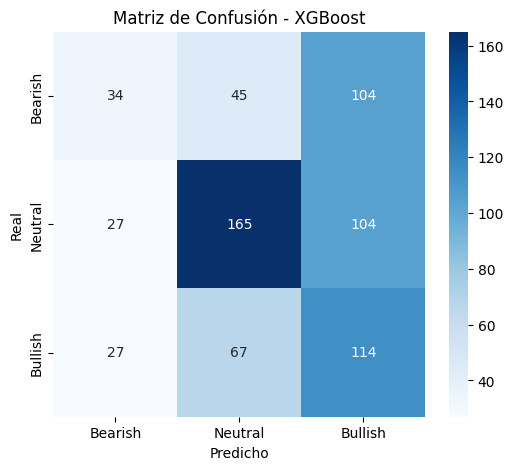


Reporte por clase:
              precision    recall  f1-score   support

     Bearish       0.39      0.19      0.25       183
     Neutral       0.60      0.56      0.58       296
     Bullish       0.35      0.55      0.43       208

    accuracy                           0.46       687
   macro avg       0.45      0.43      0.42       687
weighted avg       0.47      0.46      0.45       687



In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_XGBClassifier = model_XGBClassifier.predict(X_test)

acc = accuracy_score(y_test, y_pred_XGBClassifier)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_XGBClassifier, labels=[0,1,2])
print("\nMatriz de confusión:")
print(cm)

# Visualización con heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish','Neutral','Bullish'],
            yticklabels=['Bearish','Neutral','Bullish'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

report = classification_report(y_test, y_pred_XGBClassifier, target_names=['Bearish','Neutral','Bullish'])
print("\nReporte por clase:")
print(report)


In [25]:
list(X_train.columns)



['m1_open',
 'm2_open',
 'm3_open',
 'm4_open',
 'm5_open',
 'm6_open',
 'm7_open',
 'm8_open',
 'm9_open',
 'm10_open',
 'm11_open',
 'm12_open',
 'm13_open',
 'm14_open',
 'm15_open',
 'm1_high',
 'm2_high',
 'm3_high',
 'm4_high',
 'm5_high',
 'm6_high',
 'm7_high',
 'm8_high',
 'm9_high',
 'm10_high',
 'm11_high',
 'm12_high',
 'm13_high',
 'm14_high',
 'm15_high',
 'm1_low',
 'm2_low',
 'm3_low',
 'm4_low',
 'm5_low',
 'm6_low',
 'm7_low',
 'm8_low',
 'm9_low',
 'm10_low',
 'm11_low',
 'm12_low',
 'm13_low',
 'm14_low',
 'm15_low',
 'm1_close',
 'm2_close',
 'm3_close',
 'm4_close',
 'm5_close',
 'm6_close',
 'm7_close',
 'm8_close',
 'm9_close',
 'm10_close',
 'm11_close',
 'm12_close',
 'm13_close',
 'm14_close',
 'm15_close',
 'm1_vol',
 'm2_vol',
 'm3_vol',
 'm4_vol',
 'm5_vol',
 'm6_vol',
 'm7_vol',
 'm8_vol',
 'm9_vol',
 'm10_vol',
 'm11_vol',
 'm12_vol',
 'm13_vol',
 'm14_vol',
 'm15_vol',
 'year',
 'p1_close_open',
 'p2_close_open',
 'p3_close_open',
 'p4_close_open',
 'p5

In [26]:
!pip install lightgbm


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 40747
[LightGBM] [Info] Number of data points in the train set: 5914, number of used features: 180
[LightGBM] [Info] Start training from score -1.407830
[LightGBM] [Info] Start training from score -0.767906
[LightGBM] [Info] Start training from score -1.233255
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

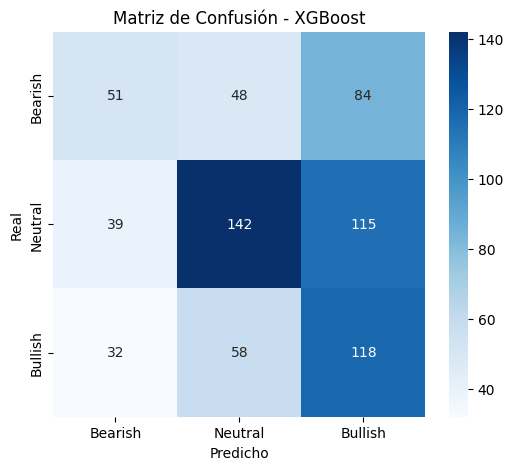


Reporte por clase:
              precision    recall  f1-score   support

     Bearish       0.42      0.28      0.33       183
     Neutral       0.57      0.48      0.52       296
     Bullish       0.37      0.57      0.45       208

    accuracy                           0.45       687
   macro avg       0.45      0.44      0.44       687
weighted avg       0.47      0.45      0.45       687



In [27]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb_model.fit(X_train, y_train)
y_pred_lgb_model = lgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_lgb_model)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_lgb_model, labels=[0,1,2])
print("\nMatriz de confusión:")
print(cm)

# Visualización con heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish','Neutral','Bullish'],
            yticklabels=['Bearish','Neutral','Bullish'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

report = classification_report(y_test, y_pred_lgb_model, target_names=['Bearish','Neutral','Bullish'])
print("\nReporte por clase:")
print(report)

In [28]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


Accuracy: 0.4323

Matriz de confusión:
[[ 19  39 125]
 [ 16 149 131]
 [ 18  61 129]]


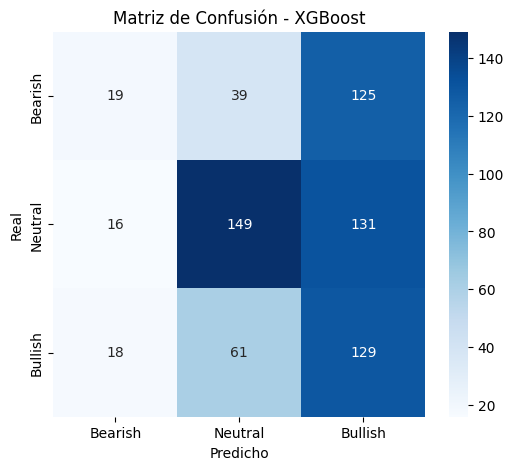


Reporte por clase:
              precision    recall  f1-score   support

     Bearish       0.36      0.10      0.16       183
     Neutral       0.60      0.50      0.55       296
     Bullish       0.34      0.62      0.44       208

    accuracy                           0.43       687
   macro avg       0.43      0.41      0.38       687
weighted avg       0.45      0.43      0.41       687



In [29]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False
)

cat_model.fit(X_train, y_train)

y_pred_cat_model = cat_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_cat_model)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_cat_model, labels=[0,1,2])
print("\nMatriz de confusión:")
print(cm)

# Visualización con heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish','Neutral','Bullish'],
            yticklabels=['Bearish','Neutral','Bullish'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

report = classification_report(y_test, y_pred_cat_model, target_names=['Bearish','Neutral','Bullish'])
print("\nReporte por clase:")
print(report)

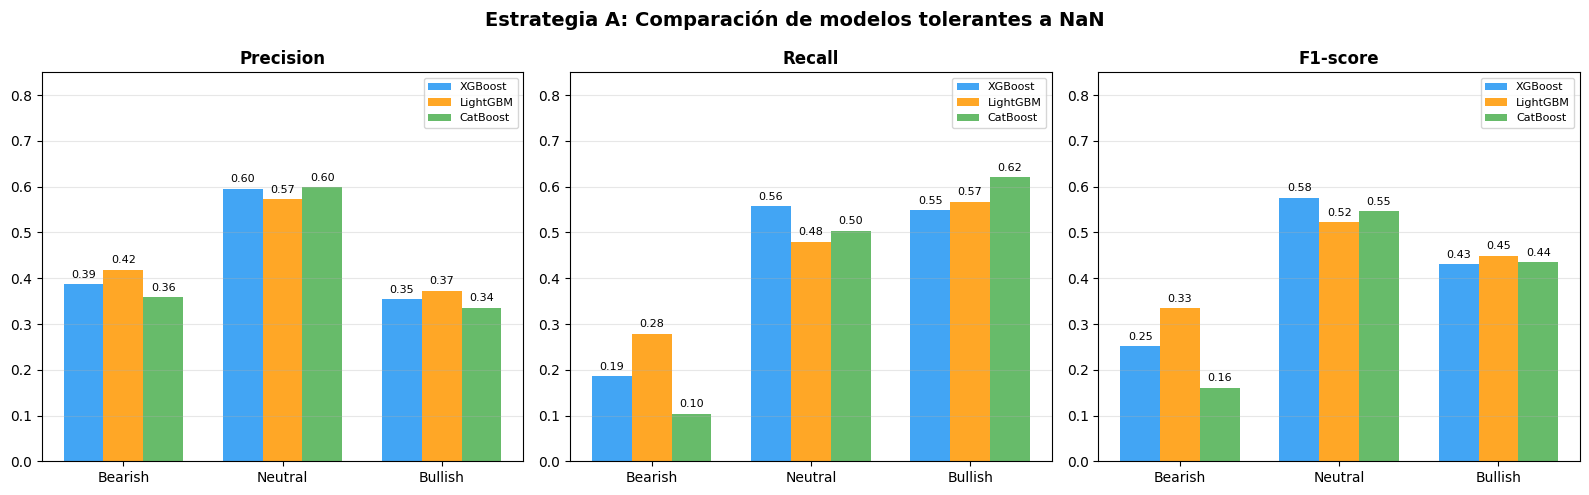

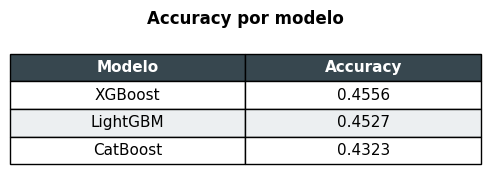

In [30]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# --- Recopilar métricas de los 3 modelos ya entrenados ---
modelos_preds = {
    'XGBoost':  y_pred_XGBClassifier,
    'LightGBM': y_pred_lgb_model,
    'CatBoost': y_pred_cat_model,
}

clases = ['Bearish', 'Neutral', 'Bullish']
colores = ['#2196F3', '#FF9800', '#4CAF50']

reports = {}
for nombre, y_pred in modelos_preds.items():
    reports[nombre] = classification_report(
        y_test, y_pred,
        target_names=clases,
        output_dict=True
    )

# Gráfico de barras agrupadas: Precision, Recall, F1
x = np.arange(len(clases))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Estrategia A: Comparación de modelos tolerantes a NaN',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, ['precision', 'recall', 'f1-score']):
    for i, (modelo, color) in enumerate(zip(reports.keys(), colores)):
        valores = [reports[modelo][clase][metrica] for clase in clases]
        bars = ax.bar(x + i * width, valores, width, label=modelo, color=color, alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metrica.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(clases)
    ax.set_ylim(0, 0.85)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Tabla de accuracy ---
fig2, ax2 = plt.subplots(figsize=(5, 2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[m, f"{reports[m]['accuracy']:.4f}"] for m in reports],
    colLabels=['Modelo', 'Accuracy'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 1.8)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECEFF1')
ax2.set_title('Accuracy por modelo', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## No se soporta NaN

Estrategia 1: Mediana.

In [31]:
from sklearn.impute import SimpleImputer

# Copia de X
X_med = X.copy()

# Definir imputador por mediana
imputer = SimpleImputer(strategy='median')
X_train_med = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_med = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_med, y_train)

y_pred_medianaLR = log_model.predict(X_test_med)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.36      0.10      0.16       183
           1       0.60      0.50      0.55       296
           2       0.34      0.62      0.44       208

    accuracy                           0.43       687
   macro avg       0.43      0.41      0.38       687
weighted avg       0.45      0.43      0.41       687

[[ 19  39 125]
 [ 16 149 131]
 [ 18  61 129]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_med)
X_test_scaled  = scaler.transform(X_test_med)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_medianaLRSS = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 19  39 125]
 [ 16 149 131]
 [ 18  61 129]]
              precision    recall  f1-score   support

           0       0.36      0.10      0.16       183
           1       0.60      0.50      0.55       296
           2       0.34      0.62      0.44       208

    accuracy                           0.43       687
   macro avg       0.43      0.41      0.38       687
weighted avg       0.45      0.43      0.41       687



In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_med, y_train)

y_pred_medianaRF = rf_model.predict(X_test_med)

print("Accuracy:", np.round(rf_model.score(X_test_med, y_test), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.4687

Confusion Matrix:
[[ 19  39 125]
 [ 16 149 131]
 [ 18  61 129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.10      0.16       183
           1       0.60      0.50      0.55       296
           2       0.34      0.62      0.44       208

    accuracy                           0.43       687
   macro avg       0.43      0.41      0.38       687
weighted avg       0.45      0.43      0.41       687



Iteration 1, loss = 1.05392909
Validation score: 0.474662
Iteration 2, loss = 0.99095180
Validation score: 0.484797
Iteration 3, loss = 0.97102326
Validation score: 0.503378
Iteration 4, loss = 0.95715844
Validation score: 0.511824
Iteration 5, loss = 0.94564426
Validation score: 0.515203
Iteration 6, loss = 0.93200600
Validation score: 0.511824
Iteration 7, loss = 0.92360534
Validation score: 0.510135
Iteration 8, loss = 0.91248536
Validation score: 0.503378
Iteration 9, loss = 0.90411962
Validation score: 0.508446
Iteration 10, loss = 0.89581165
Validation score: 0.501689
Iteration 11, loss = 0.88499533
Validation score: 0.498311
Iteration 12, loss = 0.87322938
Validation score: 0.488176
Iteration 13, loss = 0.86318547
Validation score: 0.498311
Iteration 14, loss = 0.85224660
Validation score: 0.500000
Iteration 15, loss = 0.83935393
Validation score: 0.506757
Iteration 16, loss = 0.83190659
Validation score: 0.491554
Iteration 17, loss = 0.81984489
Validation score: 0.493243
Iterat

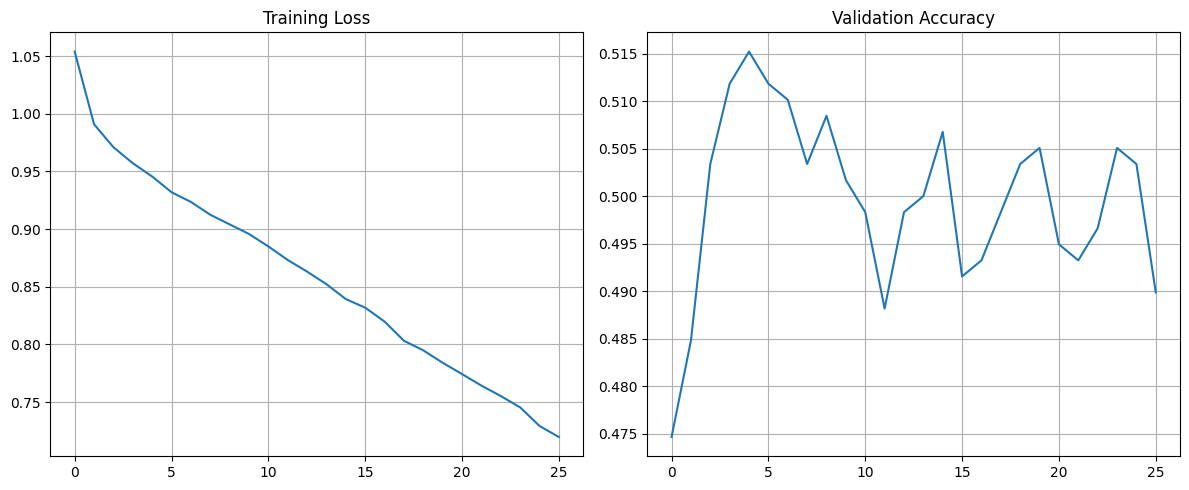

In [35]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_med)
X_test_scaled  = scaler.transform(X_test_med)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=750,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_medianaMLP = mlp_model.predict(X_test_scaled)

print("Accuracy:", np.round(mlp_model.score(X_test_scaled, y_test), 4))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mlp_model.loss_curve_)
plt.title("Training Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(mlp_model.validation_scores_)
plt.title("Validation Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


In [36]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 32),
    activation='relu',
    solver='sgd',
    alpha=0.001,
    max_iter=750,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train)
y_pred_MLPescalado = mlp_model.predict(X_test_scaled)

print("Accuracy:", np.round(mlp_model.score(X_test_scaled, y_test), 4))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Iteration 1, loss = 1.11981796
Validation score: 0.405405
Iteration 2, loss = 1.06975490
Validation score: 0.435811
Iteration 3, loss = 1.05554328
Validation score: 0.451014
Iteration 4, loss = 1.04678042
Validation score: 0.451014
Iteration 5, loss = 1.03941242
Validation score: 0.466216
Iteration 6, loss = 1.03372515
Validation score: 0.466216
Iteration 7, loss = 1.02860607
Validation score: 0.469595
Iteration 8, loss = 1.02394568
Validation score: 0.471284
Iteration 9, loss = 1.02018184
Validation score: 0.472973
Iteration 10, loss = 1.01633064
Validation score: 0.472973
Iteration 11, loss = 1.01302930
Validation score: 0.474662
Iteration 12, loss = 1.00983381
Validation score: 0.469595
Iteration 13, loss = 1.00670305
Validation score: 0.474662
Iteration 14, loss = 1.00396227
Validation score: 0.476351
Iteration 15, loss = 1.00126292
Validation score: 0.478041
Iteration 16, loss = 0.99873110
Validation score: 0.474662
Iteration 17, loss = 0.99626469
Validation score: 0.474662
Iterat

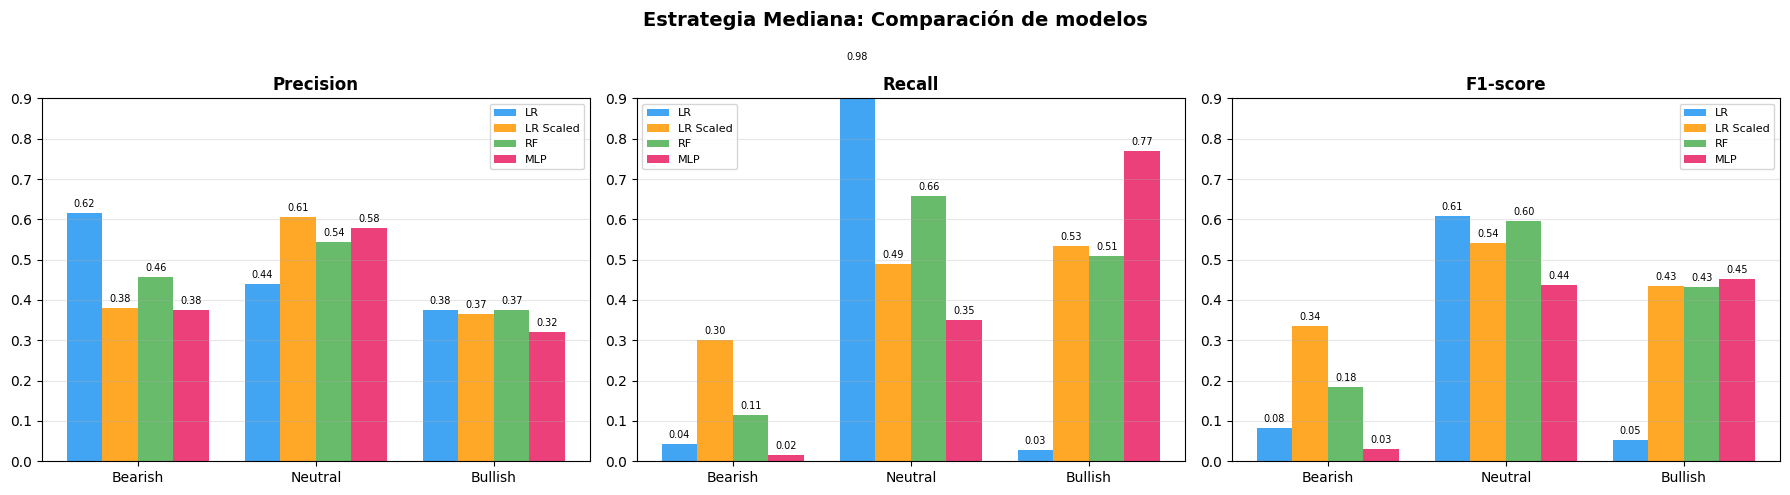

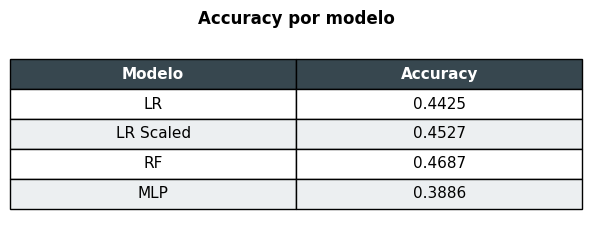

In [37]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

modelos_preds = {
    'LR':        y_pred_medianaLR,
    'LR Scaled': y_pred_medianaLRSS,
    'RF':        y_pred_medianaRF,
    'MLP':       y_pred_medianaMLP,
}

clases = ['Bearish', 'Neutral', 'Bullish']
colores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

reports = {}
for nombre, y_pred in modelos_preds.items():
    reports[nombre] = classification_report(
        y_test, y_pred,
        target_names=clases,
        output_dict=True
    )

x = np.arange(len(clases))
width = 0.2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Estrategia Mediana: Comparación de modelos',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, ['precision', 'recall', 'f1-score']):
    for i, (modelo, color) in enumerate(zip(reports.keys(), colores)):
        valores = [reports[modelo][clase][metrica] for clase in clases]
        bars = ax.bar(x + i * width, valores, width, label=modelo, color=color, alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(metrica.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(clases)
    ax.set_ylim(0, 0.9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Tabla de accuracy ---
fig2, ax2 = plt.subplots(figsize=(6, 2.5))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[m, f"{reports[m]['accuracy']:.4f}"] for m in reports],
    colLabels=['Modelo', 'Accuracy'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 1.8)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECEFF1')
ax2.set_title('Accuracy por modelo', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

No se obtienen resultados satisfactorios. Al ser valores que varían y no se repiten tal vez no sea la mejor estrategia, vamos a probar a eliminar los años que no tienen datos de minutos:

In [38]:
# Crear copias
X_train_no_nan = X_train.copy()
X_test_no_nan  = X_test.copy()
Y_train_no_nan = y_train.copy()
Y_test_no_nan  = y_test.copy()
X_train_no_nan = X_train_no_nan.dropna()
Y_train_no_nan = Y_train_no_nan.loc[X_train_no_nan.index]
X_test_no_nan = X_test_no_nan.dropna()
Y_test_no_nan = Y_test_no_nan.loc[X_test_no_nan.index]

# Logistic Regression
log_model = LogisticRegression(max_iter=20000)
log_model.fit(X_train_no_nan, Y_train_no_nan)
y_pred = log_model.predict(X_test_no_nan)

print(classification_report(Y_test_no_nan, y_pred))
print(confusion_matrix(Y_test_no_nan, y_pred))


              precision    recall  f1-score   support

           0       0.41      0.59      0.49       159
           1       0.64      0.57      0.60       266
           2       0.47      0.37      0.41       183

    accuracy                           0.51       608
   macro avg       0.51      0.51      0.50       608
weighted avg       0.53      0.51      0.52       608

[[ 94  35  30]
 [ 69 152  45]
 [ 65  51  67]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.48      0.50      0.49       159
           1       0.59      0.64      0.62       266
           2       0.54      0.46      0.50       183

    accuracy                           0.55       608
   macro avg       0.54      0.53      0.53       608
weighted avg       0.55      0.55      0.55       608


Matriz de confusión:
[[ 79  53  27]
 [ 50 170  46]
 [ 35  63  85]]


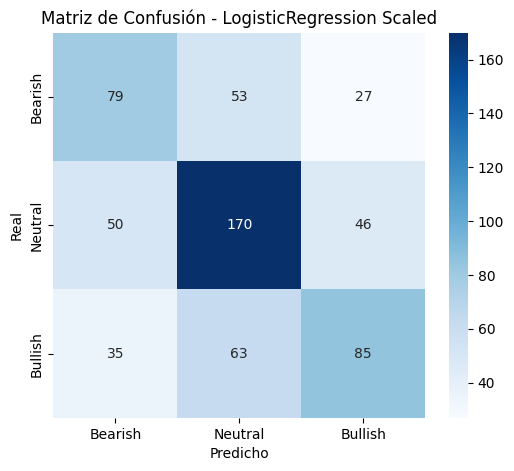

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_nan)
X_test_scaled  = scaler.transform(X_test_no_nan)


log_model = LogisticRegression(max_iter=300)
log_model.fit(X_train_scaled, Y_train_no_nan)
y_pred = log_model.predict(X_test_scaled)
acc = (y_pred == Y_test_no_nan).mean()
print(classification_report(Y_test_no_nan, y_pred))
cm = confusion_matrix(Y_test_no_nan, y_pred, labels=[0,1,2])
print("\nMatriz de confusión:")
print(cm)

# Visualización con heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish','Neutral','Bullish'],
            yticklabels=['Bearish','Neutral','Bullish'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - LogisticRegression Scaled')
plt.show()


Random Forest con 100 árboles
Accuracy: 0.4737

Matriz de confusión:
[[  5 119  35]
 [  2 237  27]
 [  3 134  46]]


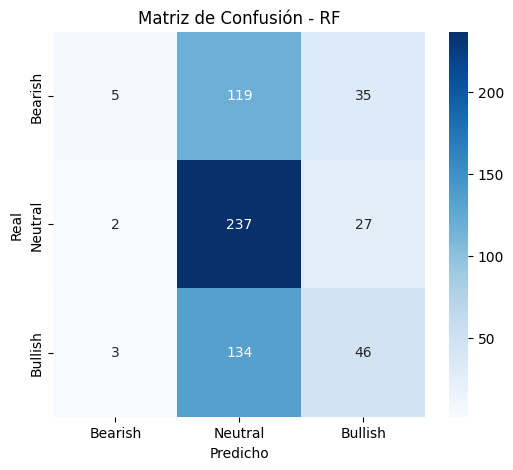


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.03      0.06       159
           1       0.48      0.89      0.63       266
           2       0.43      0.25      0.32       183

    accuracy                           0.47       608
   macro avg       0.47      0.39      0.33       608
weighted avg       0.47      0.47      0.38       608



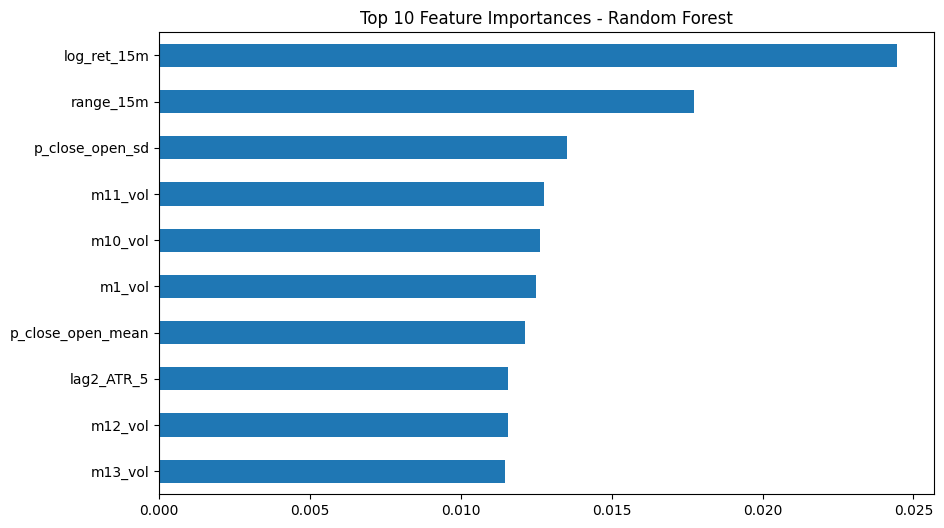

Top 10 Features: ['log_ret_15m', 'range_15m', 'p_close_open_sd', 'm11_vol', 'm10_vol', 'm1_vol', 'p_close_open_mean', 'lag2_ATR_5', 'm12_vol', 'm13_vol']
Random Forest con 200 árboles
Accuracy: 0.4819

Matriz de confusión:
[[  5 121  33]
 [  4 235  27]
 [  2 128  53]]


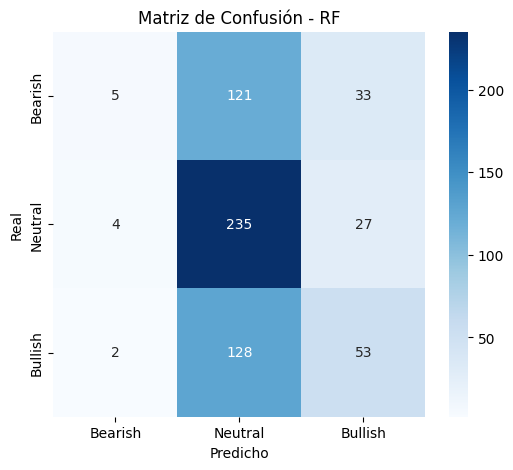


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.03      0.06       159
           1       0.49      0.88      0.63       266
           2       0.47      0.29      0.36       183

    accuracy                           0.48       608
   macro avg       0.47      0.40      0.35       608
weighted avg       0.47      0.48      0.40       608



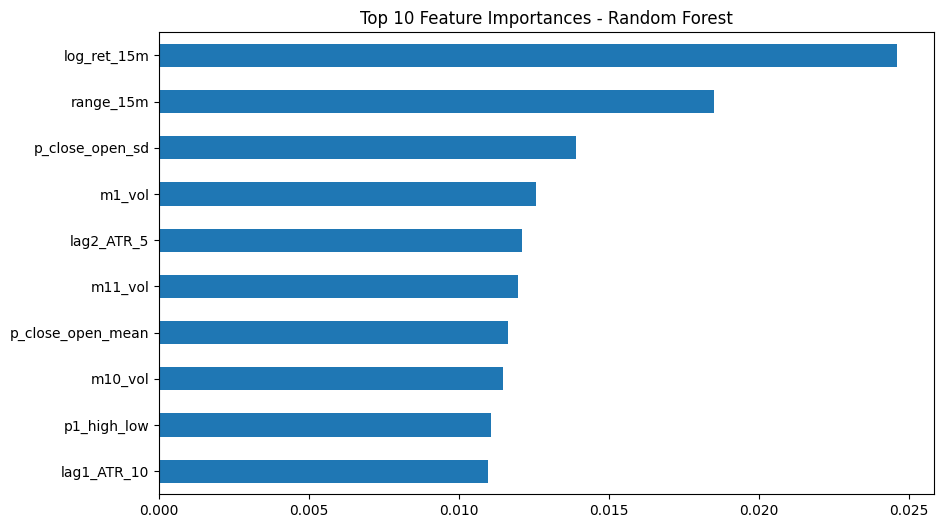

Top 10 Features: ['log_ret_15m', 'range_15m', 'p_close_open_sd', 'm1_vol', 'lag2_ATR_5', 'm11_vol', 'p_close_open_mean', 'm10_vol', 'p1_high_low', 'lag1_ATR_10']
Random Forest con 300 árboles
Accuracy: 0.477

Matriz de confusión:
[[  6 116  37]
 [  5 233  28]
 [  2 130  51]]


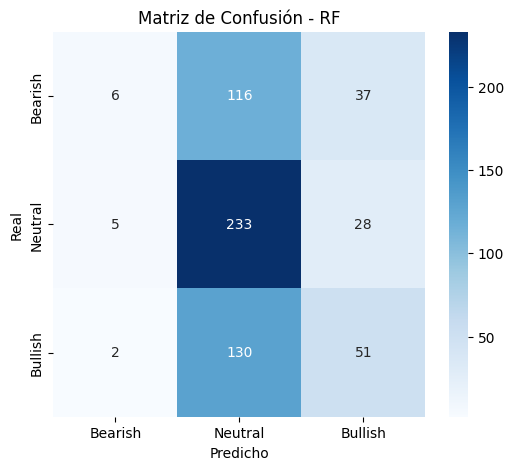


Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.04      0.07       159
           1       0.49      0.88      0.63       266
           2       0.44      0.28      0.34       183

    accuracy                           0.48       608
   macro avg       0.46      0.40      0.35       608
weighted avg       0.47      0.48      0.39       608



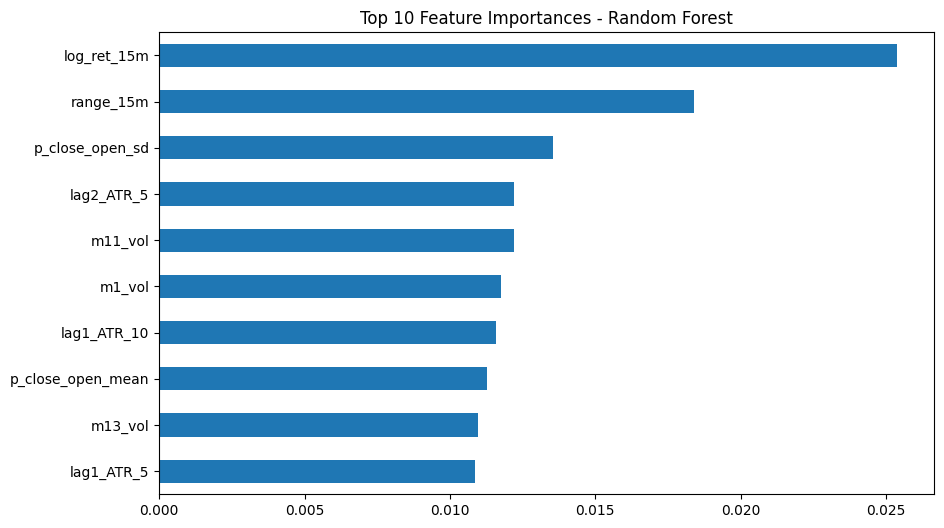

Top 10 Features: ['log_ret_15m', 'range_15m', 'p_close_open_sd', 'lag2_ATR_5', 'm11_vol', 'm1_vol', 'lag1_ATR_10', 'p_close_open_mean', 'm13_vol', 'lag1_ATR_5']
Random Forest con 400 árboles
Accuracy: 0.4737

Matriz de confusión:
[[  2 123  34]
 [  4 233  29]
 [  2 128  53]]


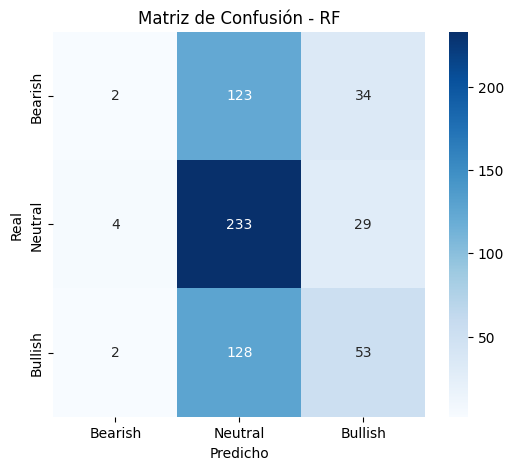


Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.01      0.02       159
           1       0.48      0.88      0.62       266
           2       0.46      0.29      0.35       183

    accuracy                           0.47       608
   macro avg       0.40      0.39      0.33       608
weighted avg       0.41      0.47      0.38       608



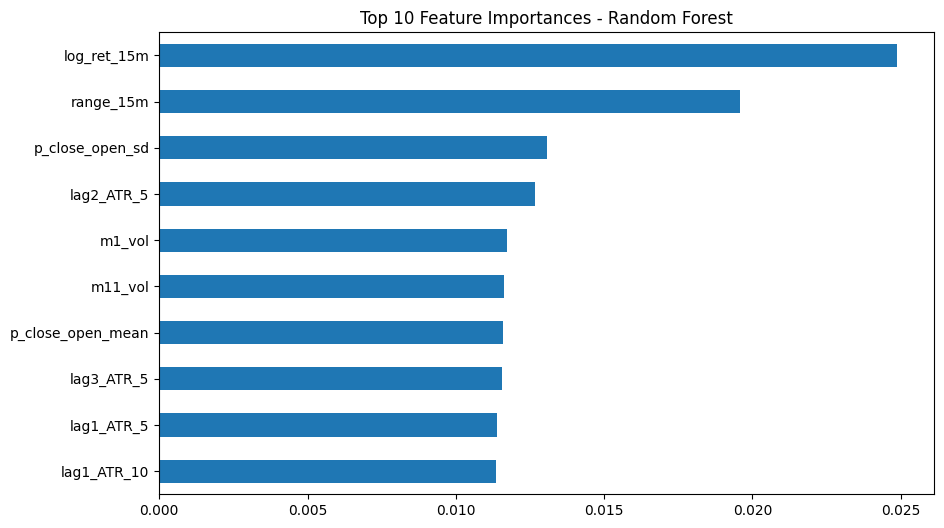

Top 10 Features: ['log_ret_15m', 'range_15m', 'p_close_open_sd', 'lag2_ATR_5', 'm1_vol', 'm11_vol', 'p_close_open_mean', 'lag3_ATR_5', 'lag1_ATR_5', 'lag1_ATR_10']
Random Forest con 500 árboles
Accuracy: 0.4753

Matriz de confusión:
[[  4 124  31]
 [  4 237  25]
 [  2 133  48]]


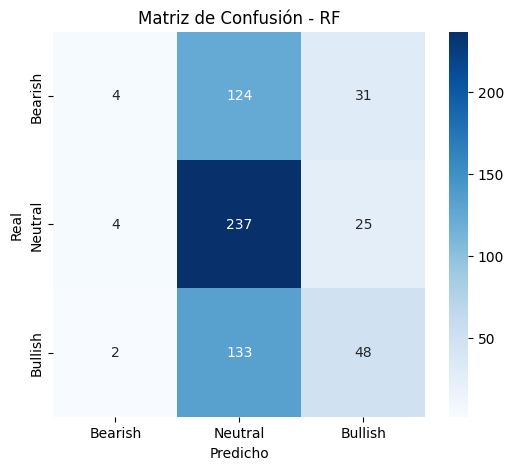


Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.03      0.05       159
           1       0.48      0.89      0.62       266
           2       0.46      0.26      0.33       183

    accuracy                           0.48       608
   macro avg       0.45      0.39      0.34       608
weighted avg       0.45      0.48      0.39       608



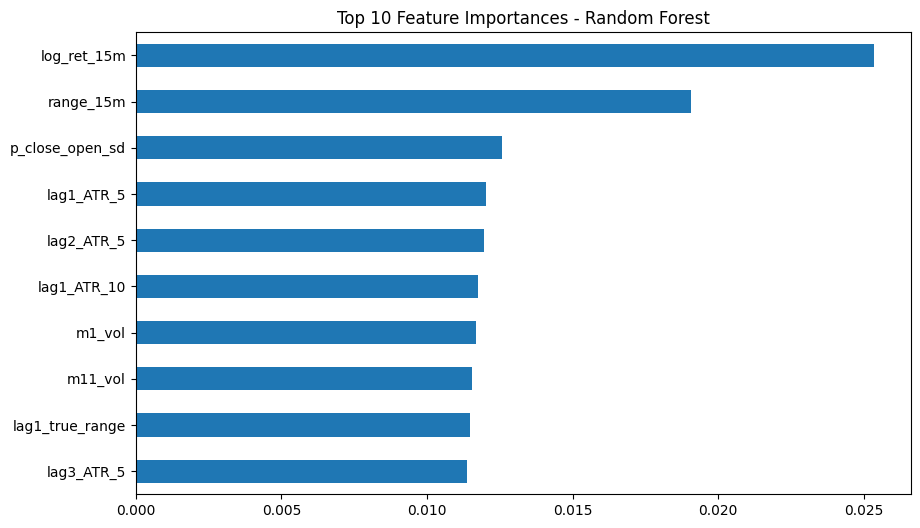

Top 10 Features: ['log_ret_15m', 'range_15m', 'p_close_open_sd', 'lag1_ATR_5', 'lag2_ATR_5', 'lag1_ATR_10', 'm1_vol', 'm11_vol', 'lag1_true_range', 'lag3_ATR_5']
Random Forest con 700 árboles
Accuracy: 0.4737

Matriz de confusión:
[[  3 126  30]
 [  4 237  25]
 [  3 132  48]]


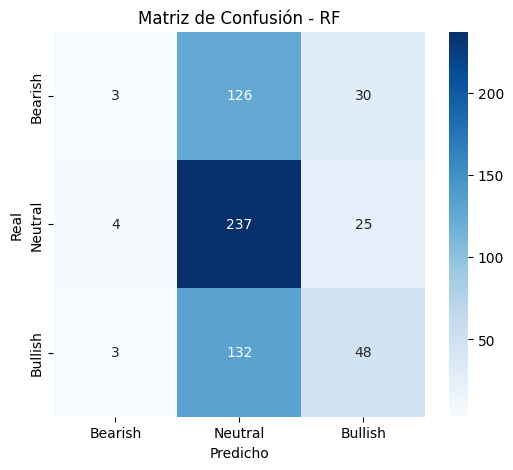


Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.02      0.04       159
           1       0.48      0.89      0.62       266
           2       0.47      0.26      0.34       183

    accuracy                           0.47       608
   macro avg       0.41      0.39      0.33       608
weighted avg       0.43      0.47      0.38       608



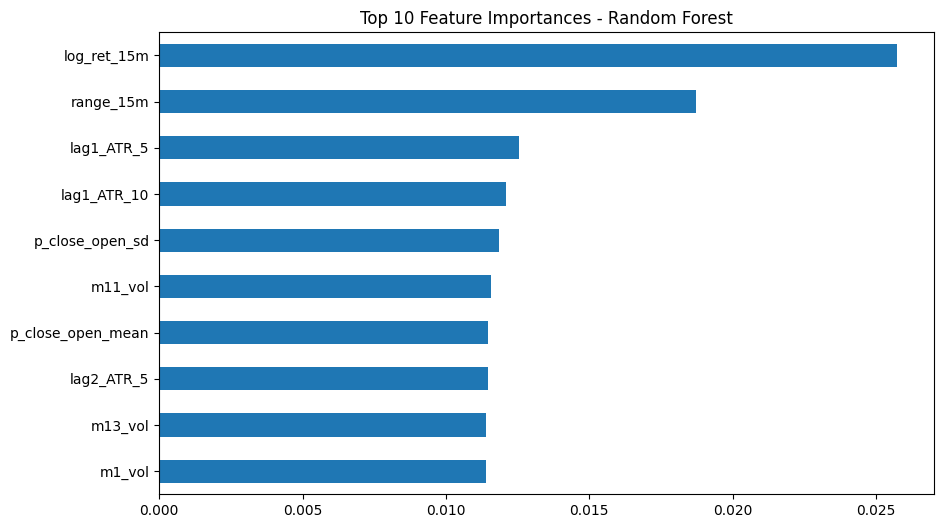

Top 10 Features: ['log_ret_15m', 'range_15m', 'lag1_ATR_5', 'lag1_ATR_10', 'p_close_open_sd', 'm11_vol', 'p_close_open_mean', 'lag2_ATR_5', 'm13_vol', 'm1_vol']
Random Forest con 1000 árboles
Accuracy: 0.4605

Matriz de confusión:
[[  3 127  29]
 [  2 233  31]
 [  1 138  44]]


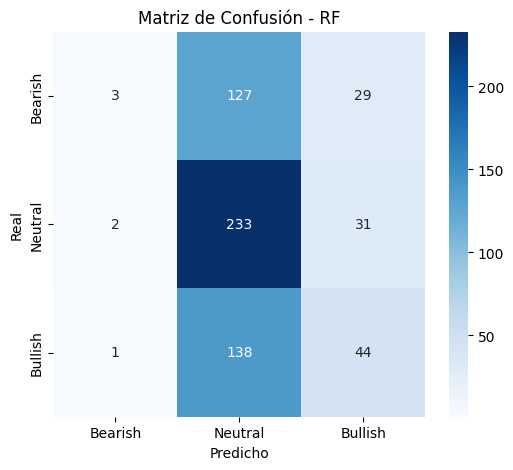


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.02      0.04       159
           1       0.47      0.88      0.61       266
           2       0.42      0.24      0.31       183

    accuracy                           0.46       608
   macro avg       0.46      0.38      0.32       608
weighted avg       0.46      0.46      0.37       608



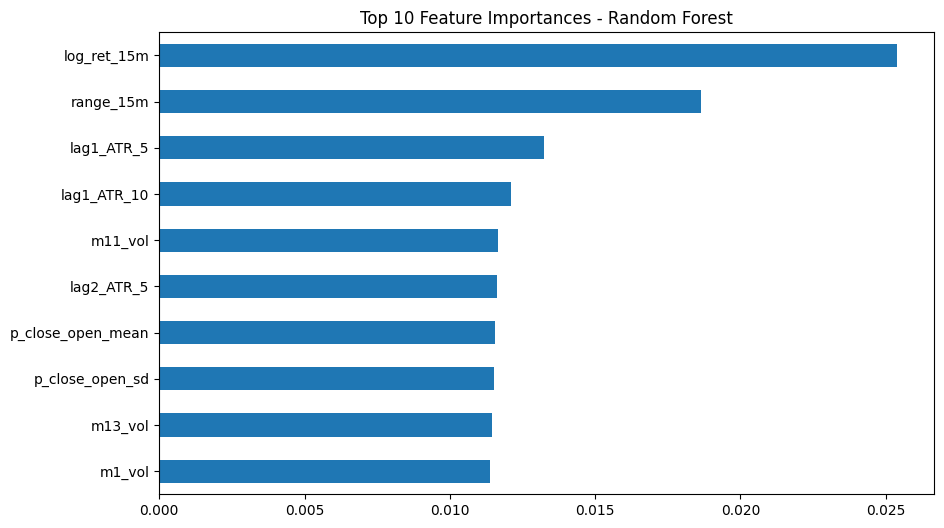

Top 10 Features: ['log_ret_15m', 'range_15m', 'lag1_ATR_5', 'lag1_ATR_10', 'm11_vol', 'lag2_ATR_5', 'p_close_open_mean', 'p_close_open_sd', 'm13_vol', 'm1_vol']


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Inicializar el modelo
for i in [100,200,300,400,500, 700, 1000]:
    print(f"Random Forest con {i} árboles")
    rf_model = RandomForestClassifier(
        n_estimators=i,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    # Entrenar con los datos sin NaN
    rf_model.fit(X_train_no_nan, Y_train_no_nan)

    y_pred = rf_model.predict(X_test_no_nan)
    print("Accuracy:", np.round(rf_model.score(X_test_no_nan, Y_test_no_nan), 4))
    cm = confusion_matrix(Y_test_no_nan, y_pred, labels=[0,1,2])
    print("\nMatriz de confusión:")
    print(cm)

    # Visualización con heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish','Neutral','Bullish'],
                yticklabels=['Bearish','Neutral','Bullish'])
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión - RF')
    plt.show()
    print("\nClassification Report:")
    print(classification_report(Y_test_no_nan, y_pred))

    # Importancia de features
    importances = pd.Series(rf_model.feature_importances_, index=X_train_no_nan.columns)
    importances = importances.sort_values(ascending=False)

    # Mostrar top 10
    plt.figure(figsize=(10,6))
    importances[:10].plot(kind='barh')
    top_10_features = importances.head(10).index.tolist()
    plt.title("Top 10 Feature Importances - Random Forest")
    plt.gca().invert_yaxis()
    plt.show()

    print("Top 10 Features:", top_10_features)


Cambio de estrategia--> Tal y cómo lo estoy haciendo se está forzando en adecuarse a la clase más neutra-> Mayoría de los datos + punto intermedio de los datos, fácil caer ahí. ALternativas:
1. Entrenar primero enseñando al modelo a que tiene que elegir si sube o baja.
2. Entrenar ya añadiendo la clase neutra. Obligar a que haya mismo número de datos. Si son pocos es una preocupación a posteriori, ahora es necesario que funcione.

¿Qué voy a hacer? -> Mantener la transformación y las tres clases-> peroooo para los días anteriores, saber eso. Probar con dos clases a partir d ahí, si sube o si baja y así se cumple con el punto 1.

In [41]:
# Años de test
test_years = [2021, 2022, 2023]

# Columnas del propio día que NO se deben usar
prohibidas = [
    'DISPLAY', 'BULLISH', 'CLOSE_OPEN',
    'D_VOL', 'D_OPENINT',
    'HINGE', 'ATR_5', 'ATR_10', 'ATR_zscore',
    'MA5', 'MA20', 'trend_MA_cross', 'vol_regime',
    'gap_abs', 'gap_pct', 'gap_dir', 'gap_zscore',
    'D_OPEN', 'D_HIGH', 'D_LOW', 'D_CLOSE',
    'date', 'y', 'log_ret', 'true_range',
    'p_HINGE_mean', 'p_HINGE_sd'
]

# Base de features
X_base = df_final.drop(columns=prohibidas)
y_base = df_final['y']

print(f"Columnas para modelado: {X_base.shape[1]}")
print(f"Filas totales: {len(df_final)}")




Columnas para modelado: 180
Filas totales: 6601


In [42]:
df_bin = df_final[df_final['y'].isin([0, 2])].copy()

# Convertimos a binario: 0 = bearish, 1 = bullish
df_bin['y_bin'] = (df_bin['y'] == 2).astype(int)

X_bin = df_bin.drop(columns=prohibidas + ['y_bin'])
y_bin = df_bin['y_bin']

X_bin_train = X_bin[~df_bin['year'].isin(test_years)]
X_bin_test  = X_bin[df_bin['year'].isin(test_years)]

y_bin_train = y_bin[~df_bin['year'].isin(test_years)]
y_bin_test  = y_bin[df_bin['year'].isin(test_years)]

print("Binario:")
print(X_bin_train.shape, X_bin_test.shape)


Binario:
(3170, 180) (391, 180)


In [43]:
rf_bin = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=40,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_bin_train, y_bin_train)

y_pred_bin = rf_bin.predict(X_bin_test)

print(classification_report(y_bin_test, y_pred_bin))
print(confusion_matrix(y_bin_test, y_pred_bin))


              precision    recall  f1-score   support

           0       0.64      0.27      0.38       183
           1       0.57      0.87      0.69       208

    accuracy                           0.59       391
   macro avg       0.60      0.57      0.53       391
weighted avg       0.60      0.59      0.54       391

[[ 49 134]
 [ 28 180]]


In [44]:
df_tri = df_final.copy()

min_n = df_tri['y'].value_counts().min()

df_tri_bal = (
    df_tri
    .groupby('y', group_keys=False)
    .apply(lambda x: x.sample(min_n, random_state=42))
)

print(df_tri_bal['y'].value_counts())
X_tri = df_tri_bal.drop(columns=prohibidas)
y_tri = df_tri_bal['y']

X_tri_train = X_tri[~df_tri_bal['year'].isin(test_years)]
X_tri_test  = X_tri[df_tri_bal['year'].isin(test_years)]

y_tri_train = y_tri[~df_tri_bal['year'].isin(test_years)]
y_tri_test  = y_tri[df_tri_bal['year'].isin(test_years)]

print("Ternario:")
print(X_tri_train.shape, X_tri_test.shape)


y
0    1630
1    1630
2    1630
Name: count, dtype: int64
Ternario:
(4371, 180) (519, 180)


/tmp/ipykernel_1306/4268593064.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_n, random_state=42))


In [45]:
rf_tri = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tri.fit(X_tri_train, y_tri_train)

y_pred_tri = rf_tri.predict(X_tri_test)

print(classification_report(y_tri_test, y_pred_tri))
print(confusion_matrix(y_tri_test, y_pred_tri))


              precision    recall  f1-score   support

           0       0.57      0.15      0.24       183
           1       0.60      0.22      0.32       159
           2       0.37      0.86      0.52       177

    accuracy                           0.42       519
   macro avg       0.52      0.41      0.36       519
weighted avg       0.51      0.42      0.36       519

[[ 28  12 143]
 [  8  35 116]
 [ 13  11 153]]


In [46]:
proba_bin = rf_bin.predict_proba(X_tri_test)[:, 1]

final_pred = []

for i, p in enumerate(proba_bin):
    if p > 0.5:
        final_pred.append(2)  # bullish
    elif p < 0.5:
        final_pred.append(0)  # bearish
    else:
        final_pred.append(1)  # neutral

final_pred = np.array(final_pred)

print(classification_report(y_tri_test, final_pred))
print(confusion_matrix(y_tri_test, final_pred))


              precision    recall  f1-score   support

           0       0.53      0.27      0.36       183
           1       0.00      0.00      0.00       159
           2       0.36      0.86      0.51       177

    accuracy                           0.39       519
   macro avg       0.30      0.38      0.29       519
weighted avg       0.31      0.39      0.30       519

[[ 49   0 134]
 [ 19   0 140]
 [ 24   0 153]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Bueno, esto no funciona, vamos a probar otra cosa pero manteniendo la misma estrategia:

In [47]:
from xgboost import XGBClassifier

xgb_bin = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_bin.fit(X_bin_train, y_bin_train)


xgb_tri = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb_tri.fit(
    X_tri_train,
    y_tri_train,
    xgb_model=xgb_bin.get_booster()
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=3, ...)

In [48]:

y_pred = xgb_tri.predict(X_tri_test)

print(classification_report(y_tri_test, y_pred))
print(confusion_matrix(y_tri_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.35      0.40       183
           1       0.53      0.33      0.41       159
           2       0.38      0.59      0.46       177

    accuracy                           0.43       519
   macro avg       0.46      0.43      0.42       519
weighted avg       0.45      0.43      0.42       519

[[ 64  20  99]
 [ 30  53  76]
 [ 45  27 105]]


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_nan)
X_test_scaled  = scaler.transform(X_test_no_nan)

# --- Datos para fase inicial (solo subida vs bajada) ---
mask_up_down = Y_train_no_nan != 1
X_bin_train = X_train_scaled[mask_up_down]
y_bin_train = Y_train_no_nan[mask_up_down].map({0:0, 2:1}).values
y_bin_train_cat = to_categorical(y_bin_train, num_classes=2)

mask_up_down_test = Y_test_no_nan != 1
X_bin_test = X_test_scaled[mask_up_down_test]
y_bin_test = Y_test_no_nan[mask_up_down_test].map({0:0, 2:1}).values
y_bin_test_cat = to_categorical(y_bin_test, num_classes=2)

model_bin = Sequential([
    Dense(128, activation='relu', input_shape=(X_bin_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

model_bin.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenamiento binario
model_bin.fit(X_bin_train, y_bin_train_cat,
              validation_data=(X_bin_test, y_bin_test_cat),
              epochs=50,
              batch_size=64)

# --- Incorporar resto dato (tres clases incluyendo neutro) ---
y_tri_train = Y_train_no_nan.values  # 0=down, 1=neutral, 2=up
y_tri_train_cat = to_categorical(y_tri_train, num_classes=3)
y_tri_test_cat = to_categorical(Y_test_no_nan.values, num_classes=3)

model_tri = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

# Copiar pesos de primera capa
model_tri.layers[0].set_weights(model_bin.layers[0].get_weights())
model_tri.layers[1].set_weights(model_bin.layers[1].get_weights())  # Dropout no tiene pesos
# La segunda capa se puede inicializar igual si quieres, pero aquí la dejamos libre

model_tri.compile(optimizer=Adam(learning_rate=0.0005),  # learning rate más pequeño
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenamiento 3 clases
model_tri.fit(X_train_scaled, y_tri_train_cat,
              validation_data=(X_test_scaled, y_tri_test_cat),
              epochs=30,
              batch_size=64)

y_pred_prob = model_tri.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test_no_nan.values, y_pred))
print(confusion_matrix(Y_test_no_nan.values, y_pred))


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5675 - loss: 0.7580 - val_accuracy: 0.5351 - val_loss: 0.7286
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6131 - loss: 0.6896 - val_accuracy: 0.5731 - val_loss: 0.8753
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6697 - loss: 0.6131 - val_accuracy: 0.5088 - val_loss: 0.7497
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6861 - loss: 0.5743 - val_accuracy: 0.5760 - val_loss: 0.9855
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6916 - loss: 0.5710 - val_accuracy: 0.5760 - val_loss: 0.8326
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7409 - loss: 0.5269 - val_accuracy: 0.5731 - val_loss: 0.8922
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7245 - loss: 0.5294 - val_accuracy: 0.5906 - val_loss: 0.7639
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7792 - loss: 0.4907 - val_accuracy: 0.5702 - val_loss: 0.7852
Epoch 9/50


In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_nan)
X_test_scaled  = scaler.transform(X_test_no_nan)
y_train_cat = tf.keras.utils.to_categorical(Y_train_no_nan.values, num_classes=3)
y_test_cat  = tf.keras.utils.to_categorical(Y_test_no_nan.values, num_classes=3)

configs = [
    {'layers':[128,64], 'dropout':0.2, 'lr':0.001},
    {'layers':[256,128,64], 'dropout':0.3, 'lr':0.001},
    {'layers':[64,32], 'dropout':0.1, 'lr':0.0005},
]

results = []

for cfg in configs:
    model = Sequential()
    model.add(Dense(cfg['layers'][0], activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(cfg['dropout']))

    for neurons in cfg['layers'][1:]:
        model.add(Dense(neurons, activation='relu'))

    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=cfg['lr']),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train_scaled, y_train_cat, epochs=30, batch_size=64, verbose=0)

    y_pred_prob = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_prob, axis=1)

    report = classification_report(Y_test_no_nan.values, y_pred, output_dict=True)
    results.append(report)

for r in results:
    print(r)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
{'0': {'precision': 0.33544303797468356, 'recall': 0.3333333333333333, 'f1-score': 0.334384858044164, 'support': 159.0}, '1': {'precision': 0.5761904761904761, 'recall': 0.4548872180451128, 'f1-score': 0.5084033613445378, 'support': 266.0}, '2': {'precision': 0.32916666666666666, 'recall': 0.43169398907103823, 'f1-score': 0.3735224586288416, 'support': 183.0}, 'accuracy': 0.4161184210526316, 'macro avg': {'precision': 0.4136000602772754, 'recall': 0.40663818014982817, 'f1-score': 0.4054368926725145, 'support': 608.0}, 'weighted avg': {'precision': 0.43888093701421277, 'recall': 0.4161184210526316, 'f1-score': 0.4222978560456368, 'support': 608.0}}
{'0': {'precision': 0.4666666666666667, 'recall': 0.0440251572327044, 'f1-score': 0.08045977011494253, 'support': 159.0}, '1': {'precision': 0.482897384305835, 'recall': 0.9022556390977443, 'f1-score': 0.6290956749672346, 'support': 266.0}, '2': {'precision': 0.46875, 'recall': 0.2459016393442623, 'f1-s

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_nan)
X_test_scaled  = scaler.transform(X_test_no_nan)
y_train_cat = tf.keras.utils.to_categorical(Y_train_no_nan.values, num_classes=3)
y_test_cat  = tf.keras.utils.to_categorical(Y_test_no_nan.values, num_classes=3)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_no_nan),
    y=Y_train_no_nan
)
class_weights_dict = dict(enumerate(class_weights))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test_no_nan, y_pred))
print(confusion_matrix(Y_test_no_nan, y_pred))


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4268 - loss: 1.4155 - val_accuracy: 0.4494 - val_loss: 1.1130 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5173 - loss: 1.1363 - val_accuracy: 0.4494 - val_loss: 1.1854 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5447 - loss: 1.0261 - val_accuracy: 0.4211 - val_loss: 1.2122 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5610 - loss: 0.9630 - val_accuracy: 0.4211 - val_loss: 1.1945 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5945 - loss: 0.9016 - val_accuracy: 0.4372 - val_loss: 1.1789 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6220 - loss: 0.8730 - val_accuracy: 0.4453 - val_loss: 1.3936 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6352 - loss: 0.8132 - val_accuracy: 0

In [52]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_nan)
X_test_scaled  = scaler.transform(X_test_no_nan)
y_train_cat = tf.keras.utils.to_categorical(Y_train_no_nan.values, num_classes=3)
y_test_cat  = tf.keras.utils.to_categorical(Y_test_no_nan.values, num_classes=3)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_no_nan),
    y=Y_train_no_nan
)
class_weights_dict = dict(enumerate(class_weights))


early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)


layer_options = [
    [128, 64],
    [128, 128],
    [256, 128, 64],
    [128, 128, 64]
]
dropout_options = [
    [0.2, 0.2],
    [0.25, 0.25],
    [0.3, 0.2, 0.1],
    [0.25, 0.2, 0.1]
]
learning_rates = [0.001, 0.003, 0.005]

results = []

for layers_cfg in layer_options:
    for dropouts_cfg in dropout_options:
        if len(layers_cfg) != len(dropouts_cfg):
            continue
        for lr in learning_rates:
            print(f"\n=== Experimento: Layers={layers_cfg}, Dropout={dropouts_cfg}, LR={lr} ===")

            model = Sequential()
            model.add(Dense(layers_cfg[0], activation=None, input_shape=(X_train_scaled.shape[1],)))
            model.add(BatchNormalization())
            model.add(Activation('relu'))
            model.add(Dropout(dropouts_cfg[0]))

            for u, d in zip(layers_cfg[1:], dropouts_cfg[1:]):
                model.add(Dense(u, activation=None))
                model.add(BatchNormalization())
                model.add(Activation('relu'))
                model.add(Dropout(d))

            model.add(Dense(3, activation='softmax'))

            model.compile(
                optimizer=Adam(learning_rate=lr),
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                X_train_scaled, y_train_cat,
                validation_split=0.2,
                epochs=50,
                batch_size=128,
                class_weight=class_weights_dict,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )

            y_pred_prob = model.predict(X_test_scaled)
            y_pred = np.argmax(y_pred_prob, axis=1)

            report = classification_report(Y_test_no_nan, y_pred, output_dict=True)
            acc = report['accuracy']
            results.append({
                'layers': layers_cfg,
                'dropouts': dropouts_cfg,
                'lr': lr,
                'accuracy': acc,
                'report': report,
                'conf_matrix': confusion_matrix(Y_test_no_nan, y_pred)
            })

best_exp = max(results, key=lambda x: x['accuracy'])
print("\n=== Mejor Experimento ===")
print(f"Layers: {best_exp['layers']}")
print(f"Dropouts: {best_exp['dropouts']}")
print(f"LR: {best_exp['lr']}")
print(f"Accuracy: {best_exp['accuracy']:.4f}")
print("Classification report:")
print(pd.DataFrame(best_exp['report']).transpose())
print("Confusion matrix:")
print(best_exp['conf_matrix'])



=== Experimento: Layers=[128, 64], Dropout=[0.2, 0.2], LR=0.001 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

=== Experimento: Layers=[128, 64], Dropout=[0.2, 0.2], LR=0.003 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

=== Experimento: Layers=[128, 64], Dropout=[0.2, 0.2], LR=0.005 ===


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/keras/src

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

=== Experimento: Layers=[128, 128, 64], Dropout=[0.25, 0.2, 0.1], LR=0.005 ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/keras/src

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  

=== Mejor Experimento ===
Layers: [128, 64]
Dropouts: [0.25, 0.25]
LR: 0.005
Accuracy: 0.4934
Classification report:
              precision    recall  f1-score     support
0              0.428571  0.358491  0.390411  159.000000
1              0.511579  0.913534  0.655870  266.000000
2              0.000000  0.000000  0.000000  183.000000
accuracy       0.493421  0.493421  0.493421    0.493421
macro avg      0.313383  0.424008  0.348760  608.000000
weighted avg   0.335893  0.493421  0.389041  608.000000
Confusion matrix:
[[ 57 102   0]
 [ 23 243   0]
 [ 53 130   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_nan)
X_test_scaled  = scaler.transform(X_test_no_nan)
y_train_cat = tf.keras.utils.to_categorical(Y_train_no_nan.values, num_classes=3)
y_test_cat  = tf.keras.utils.to_categorical(Y_test_no_nan.values, num_classes=3)


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_no_nan),
    y=Y_train_no_nan
)
class_weights_dict = dict(enumerate(class_weights))


early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)


layer_options = [
    [128, 64],
    [128, 128],
    [256, 128, 64],
    [128, 128, 64]
]
dropout_options = [
    [0.2, 0.2],
    [0.25, 0.25],
    [0.3, 0.2, 0.1],
    [0.25, 0.2, 0.1]
]
learning_rates = [0.001, 0.003, 0.005]

results = []


print(f"\n=== Experimento: Layers={[128, 64]}, Dropout={[0.2, 0.2]}, LR={0.003} ===")

model = Sequential()
model.add(Dense(128, activation=None, input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))


model.add(Dense(64, activation=None))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(Y_test_no_nan, y_pred, output_dict=True)
acc = report['accuracy']
results.append({
    'layers': layers_cfg,
    'dropouts': [0.2, 0.2],
    'lr': 0.003,
    'accuracy': acc,
    'report': report,
    'conf_matrix': confusion_matrix(Y_test_no_nan, y_pred)
})


best_exp = max(results, key=lambda x: x['accuracy'])
print("\n=== Mejor Experimento ===")
print(f"Layers: {best_exp['layers']}")
print(f"Dropouts: {best_exp['dropouts']}")
print(f"LR: {best_exp['lr']}")
print(f"Accuracy: {best_exp['accuracy']:.4f}")
print("Classification report:")
print(pd.DataFrame(best_exp['report']).transpose())
print("Confusion matrix:")
print(best_exp['conf_matrix'])



=== Experimento: Layers=[128, 64], Dropout=[0.2, 0.2], LR=0.003 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

=== Mejor Experimento ===
Layers: [128, 128, 64]
Dropouts: [0.2, 0.2]
LR: 0.003
Accuracy: 0.4967
Classification report:
              precision    recall  f1-score     support
0              0.600000  0.094340  0.163043  159.000000
1              0.515625  0.868421  0.647059  266.000000
2              0.414815  0.306011  0.352201  183.000000
accuracy       0.496711  0.496711  0.496711    0.496711
macro avg      0.510147  0.422924  0.387435  608.000000
weighted avg   0.507348  0.496711  0.431734  608.000000
Confusion matrix:
[[ 15  98  46]
 [  2 231  33]
 [  8 119  56]]
